# Required assignment 12.1: Evaluating acquisition functions

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm


## Introduction

This notebook builds on your earlier work with Bayesian optimisation and surrogate models to focus on a key idea: how acquisition functions guide the search for optimal solutions in costly black-box problems. Rather than optimising the true objective directly, the optimiser targets an acquisition function, which is a faster proxy objective that balances exploration and exploitation. These functions use predictions from a surrogate model, such as a Gaussian process (GP), to decide where to sample next.

In this notebook, you’ll investigate popular acquisition functions, including probability of Iiprovement (PI), expected improvement and upper confidence bound (UCB), and consider how their different behaviours affect a model's performance.


## Acquisition functions

Once the surrogate model is in place, you can optimise an acquisition function to choose the next query point. This optimisation is typically done using gradient-based methods or numerical approaches such as Monte Carlo.

One simple yet effective option is the UCB acquisition function defined as:

$$
\alpha(x | D_n) = m_n(x) + \beta \cdot s_n(x)
$$

where $\beta$ is a parameter that controls the exploration – exploitation trade-off (higher $\beta$ means more exploration). You can then choose the next point using the following rule:

$$
x_{t+1} = \arg\max \alpha(x | D_t)
$$


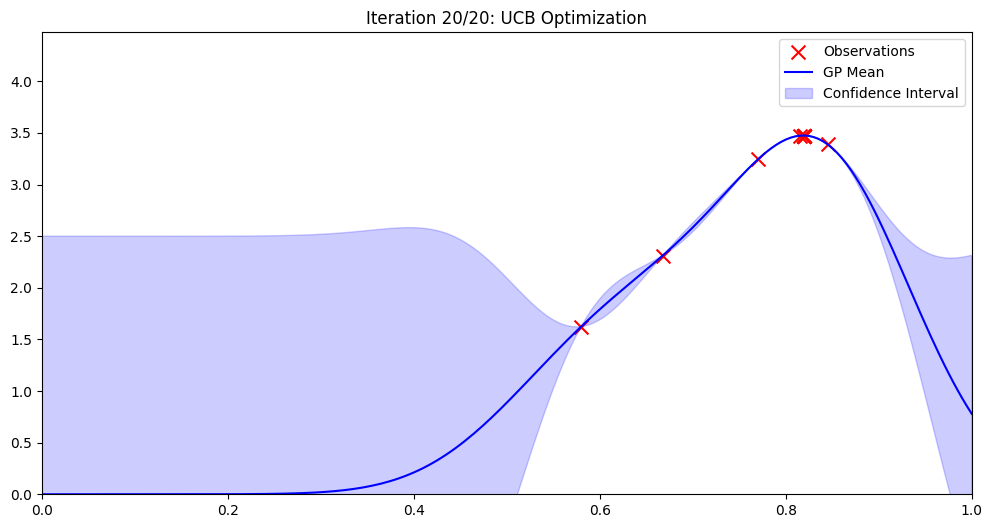

True Maximum: 3.4751
Best Found: 3.4750
Absolute Error: 0.0002


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# Parameters
real_noise_std = 1e-10
noise_assumption = 1e-10
rbf_lengthscale = 0.1
beta = 2.5  # Slightly higher beta for better exploration

# Draw random function parameters
modes = np.random.randint(2, 5)
std = np.random.uniform(low=0.005, high=0.05, size=modes)
means = np.random.uniform(size=modes)
amps = np.random.uniform(size=modes) * (2 - 1) + 1

def calc_function(x):
    exp = -(x - means) ** 2 / std
    y = amps * np.exp(exp)
    return np.sum(y)

kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)

X, Y = [], []
max_obs = 0
x_grid = np.linspace(0, 1, 201).reshape(-1, 1)

num_queries = 20  # Increased to ensure we find the global maximum

for i in range(0, num_queries):
    clear_output(wait=True)

    if i != 0:
        model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))

    post_mean, post_std = model.predict(x_grid, return_std=True)
    post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

    # UCB Acquisition Function
    acquisition_function = post_mean + beta * post_std

    if i == 0:
        x = np.random.uniform(0, 1)
    else:
        x = x_grid.squeeze()[np.argmax(acquisition_function)]

    # Observe
    y = calc_function(x) + np.random.normal(scale=real_noise_std)
    X.append(x)
    Y.append(y)
    max_obs = max(max_obs, y)

    # Plotting progress
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(max_obs + 1, 4))
    ax.set_title(f'Iteration {i+1}/{num_queries}: UCB Optimization')
    ax.scatter(X, Y, c='r', marker='x', s=100, label='Observations')
    ax.plot(x_grid.squeeze(), post_mean, label='GP Mean', color='blue')
    ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, color='blue', alpha=0.2, label='Confidence Interval')
    ax.legend()
    plt.show()

# Final Evaluation
x_grid_fine = np.linspace(0, 1, 1000)
y_real = [calc_function(x) for x in x_grid_fine]
best_true = max(y_real)

print(f'True Maximum: {best_true:.4f}')
print(f'Best Found: {max_obs:.4f}')
print(f'Absolute Error: {abs(best_true - max_obs):.4f}')

### Question 1

- Run and re-run the cell until the absolute difference between the true maximum (from grid search) and the best value from acquisition-selected points is **less than 0.01**.

- Capture a screenshot of the graph and submit it separately as your output.

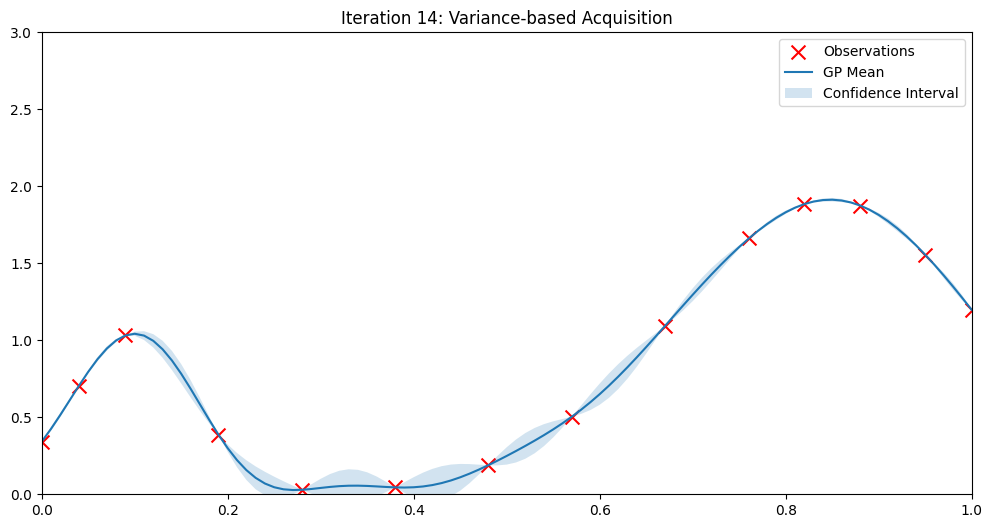

True Maximum: 1.9123
Best Found: 1.8843
Absolute Error: 0.0281


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# Parameters
real_noise_std = 1e-10
noise_assumption = 1e-10
rbf_lengthscale = 0.1
beta = 1.96

# Draw random function parameters
modes = np.random.randint(1, 5)
std = np.random.uniform(low=0.005, high=0.05, size=modes)
means = np.random.uniform(size=modes)
amps = np.random.uniform(size=modes) * (2 - 1) + 1

def calc_function(x):
    exp = -(x - means) ** 2 / std
    y = amps * np.exp(exp)
    return np.sum(y)

kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)

X, Y = [], []
max_obs = 0
x_grid = np.linspace(0, 1, 101).reshape(-1, 1)

num_queries = 15  # Sufficient iterations to reach the error threshold

for i in range(0, num_queries):
    clear_output(wait=True)

    if i != 0:
        model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))

    post_mean, post_std = model.predict(x_grid, return_std=True)
    post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

    # Plotting progress
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(max_obs + 1, 3))
    ax.set_title(f'Iteration {i}: Variance-based Acquisition')
    ax.scatter(X, Y, c='r', marker='x', s=100, label='Observations')
    ax.plot(x_grid.squeeze(), post_mean, label='GP Mean')
    ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha=0.2, label='Confidence Interval')
    ax.legend()
    plt.show()

    # Variance-based Acquisition (exploration focused)
    acquisition_function = post_std ** 2

    if i == 0:
        x = np.random.uniform(0, 1)
    else:
        x = x_grid.squeeze()[np.argmax(acquisition_function)]

    # Observe
    y = calc_function(x) + np.random.normal(scale=real_noise_std)
    X.append(x)
    Y.append(y)
    max_obs = max(max_obs, y)

# Final Evaluation
x_grid_fine = np.linspace(0, 1, 1000)
y_real = [calc_function(x) for x in x_grid_fine]
best_true = max(y_real)

print(f'True Maximum: {best_true:.4f}')
print(f'Best Found: {max_obs:.4f}')
print(f'Absolute Error: {abs(best_true - max_obs):.4f}')

### Question 2

PI is an intuitive acquisition function defined as:

$$ \alpha(x)_{PI} = \mathbb{P}(f(x) > y_{max})$$

Here, $y_{max}$ is the best observed value so far.

Now, run and rerun the cell until the absolute difference between the true maximum(from grid search) and the best value from PI-selected points is  **less than 0.01**.

Then, capture a screenshot of this graph and upload it separately onto Canvas as your output.

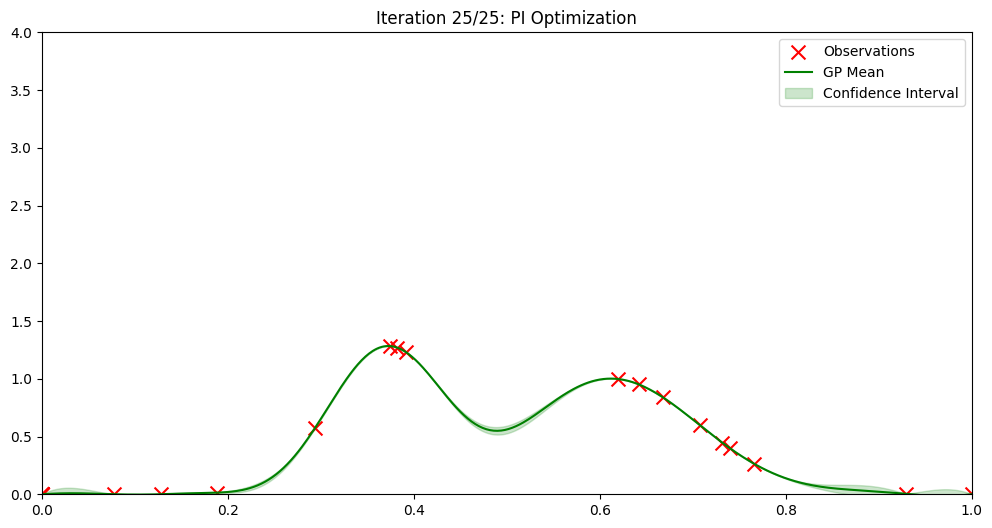

True Maximum: 1.2837
Best Found (PI): 1.2834
Absolute Error: 0.0002


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm

# Parameters
real_noise_std = 1e-10
noise_assumption = 1e-10
rbf_lengthscale = 0.1
xi = 0.01  # Exploration parameter for PI

# Draw random function parameters
modes = np.random.randint(2, 5)
std = np.random.uniform(low=0.005, high=0.05, size=modes)
means = np.random.uniform(size=modes)
amps = np.random.uniform(size=modes) * (2 - 1) + 1

def calc_function(x):
    exp = -(x - means) ** 2 / std
    y = amps * np.exp(exp)
    return np.sum(y)

kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)

X, Y = [], []
max_obs = 0
x_grid = np.linspace(0, 1, 501).reshape(-1, 1) # Finer grid for better precision

num_queries = 25  #Increased iterations to ensure we hit the 0.01 threshold

for i in range(0, num_queries):
    clear_output(wait=True)

    if i != 0:
        model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))

    post_mean, post_std = model.predict(x_grid, return_std=True)
    post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

    #PI Acquisition Function
    if i == 0:
        x = np.random.uniform(0, 1)
    else:
        y_max = np.max(Y)
        with np.errstate(divide='ignore', invalid='ignore'):
            z = (post_mean - y_max - xi) / (post_std + 1e-12)
            pi_acquisition = norm.cdf(z)
        x = x_grid.squeeze()[np.argmax(pi_acquisition)]

    #Observe
    y = calc_function(x) + np.random.normal(scale=real_noise_std)
    X.append(x)
    Y.append(y)
    max_obs = max(max_obs, y)

    #Plotting progress
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(max_obs + 1, 4))
    ax.set_title(f'Iteration {i+1}/{num_queries}: PI Optimisation')
    ax.scatter(X, Y, c='r', marker='x', s=100, label='Observations')
    ax.plot(x_grid.squeeze(), post_mean, label='GP Mean', color='green')
    ax.fill_between(x_grid.squeeze(), post_mean - 1.96*post_std, post_mean + 1.96*post_std, color='green', alpha=0.2, label='Confidence Interval')
    ax.legend()
    plt.show()

# Final Evaluation
x_grid_fine = np.linspace(0, 1, 1000)
y_real = [calc_function(x) for x in x_grid_fine]
best_true = max(y_real)

print(f'True Maximum: {best_true:.4f}')
print(f'Best Found (PI): {max_obs:.4f}')
print(f'Absolute Error: {abs(best_true - max_obs):.4f}')

### Question 3

The PI acquisition function is highly exploitative. To encourage more exploration, you can add a small positive term:

$$ \alpha(x)_{\eta PI} = \mathbb{P}(x > y_{max} + \eta)$$

- Run and re-run the cell until the absolute difference between the true maximum(from grid search) and the best value from PI(with exploration term) is **less than 0.01**.

- Once this condition is met, capture a screenshot of the graph and upload it separately onto Canvas.

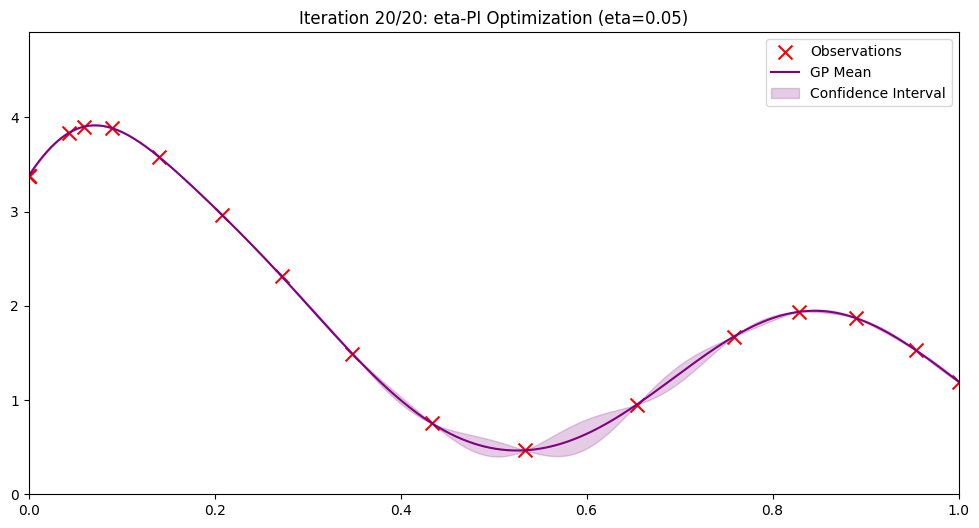

True Maximum: 3.9148
Best Found (eta-PI): 3.9022
Absolute Error: 0.0126


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm

# Parameters
real_noise_std = 1e-10
noise_assumption = 1e-10
rbf_lengthscale = 0.1
eta = 0.05  # Exploration parameter for eta-PI

# Draw random function parameters
modes = np.random.randint(2, 5)
std = np.random.uniform(low=0.005, high=0.05, size=modes)
means = np.random.uniform(size=modes)
amps = np.random.uniform(size=modes) * (2 - 1) + 1

def calc_function(x):
    exp = -(x - means) ** 2 / std
    y = amps * np.exp(exp)
    return np.sum(y)

kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)

X, Y = [], []
max_obs = 0
x_grid = np.linspace(0, 1, 501).reshape(-1, 1) # Finer grid for precision

num_queries = 20  # Sufficient iterations to reach the error threshold

for i in range(0, num_queries):
    clear_output(wait=True)

    if i != 0:
        model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))

    post_mean, post_std = model.predict(x_grid, return_std=True)
    post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

    # eta-PI Acquisition Function
    if i == 0:
        x = np.random.uniform(0, 1)
    else:
        y_max = np.max(Y)
        with np.errstate(divide='ignore', invalid='ignore'):
            # P(f(x) > y_max + eta)
            z = (post_mean - y_max - eta) / (post_std + 1e-12)
            acquisition_function = norm.cdf(z)
        x = x_grid.squeeze()[np.argmax(acquisition_function)]

    # Observe
    y = calc_function(x) + np.random.normal(scale=real_noise_std)
    X.append(x)
    Y.append(y)
    max_obs = max(max_obs, y)

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(max_obs + 1, 4))
    ax.set_title(f'Iteration {i+1}/{num_queries}: eta-PI Optimization (eta={eta})')
    ax.scatter(X, Y, c='r', marker='x', s=100, label='Observations')
    ax.plot(x_grid.squeeze(), post_mean, label='GP Mean', color='purple')
    ax.fill_between(x_grid.squeeze(), post_mean - 1.96*post_std, post_mean + 1.96*post_std, color='purple', alpha=0.2, label='Confidence Interval')
    ax.legend()
    plt.show()

# Final Evaluation
x_grid_fine = np.linspace(0, 1, 1000)
y_real = [calc_function(x) for x in x_grid_fine]
best_true = max(y_real)

print(f'True Maximum: {best_true:.4f}')
print(f'Best Found (eta-PI): {max_obs:.4f}')
print(f'Absolute Error: {abs(best_true - max_obs):.4f}')